In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ---------------- LOAD DATA ----------------
data = pd.read_csv("newDataset_with_demand.csv")

# Clean column names
data.columns = data.columns.str.strip()
data.dropna(inplace=True)

print("Columns:", data.columns)

# ---------------- FEATURES ----------------
features = ["population", "capacity", "inflow", "outflow", "reservoirlevel"]
target = "Water_Demand"

# Safety check
for col in features + [target]:
    if col not in data.columns:
        raise ValueError(f"❌ Column '{col}' not found")

X = data[features]
y = data[target]

# ---------------- SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- RANDOM FOREST ----------------
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n🔹 Random Forest")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# ---------------- LINEAR REGRESSION ----------------
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)

# ---------------- USER INPUT ----------------
print("\n--- Enter Input Values ---")

population = int(input("Population: "))
capacity = float(input("Capacity: "))
inflow = float(input("Inflow: "))
outflow = float(input("Outflow: "))
reservoirlevel = float(input("Reservoir Level: "))

new_data = pd.DataFrame({
    "population": [population],
    "capacity": [capacity],
    "inflow": [inflow],
    "outflow": [outflow],
    "reservoirlevel": [reservoirlevel]
})

future = model.predict(new_data)[0]
print(f"\n✅ Predicted Water Demand: {future:.2f}")

# ---------------- VISUALIZATION ----------------

# Feature Importance
plt.figure()
sns.barplot(x=model.feature_importances_, y=features)
plt.title("Feature Importance")
plt.show()

# RF Plot
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("RF: Actual vs Predicted")
plt.show()

# LR Plot
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("LR: Actual vs Predicted")
plt.show()

# Histogram
plt.figure()
sns.histplot(y_pred, bins=20)
plt.axvline(future, color='red')
plt.title("Prediction Distribution")
plt.show()

# Input vs Prediction
labels = ["Pop", "Cap", "In", "Out", "Level", "Pred"]
values = [population, capacity, inflow, outflow, reservoirlevel, future]

plt.figure()
plt.bar(labels, values)
plt.title("Input vs Prediction")
plt.show()

Columns: Index(['jan-feb', 'feb', 'reservoirlevel', 'jan', 'nov', 'jul', 'apr', 'year',
       'district', 'sep', 'state_ut_name', 'capacity', 'jun-sep', 'oct-dec',
       'oct', 'may', 'outflow', 'mar-may', 'population', 'dec', 'inflow',
       'aug', 'annual', 'jun', 'mar', 'Water_Demand'],
      dtype='object')

🔹 Random Forest
MSE: 12377.339521696409
R2: 0.9999626666249842

--- Enter Input Values ---


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score  
import joblib 
import numpy as np   

In [314]:
# import pandas as pd
# import numpy as np

# Load your dataset
data = pd.read_csv("newDataset.csv")

# Clean column names
data.columns = data.columns.str.strip()

# Set seed (same result every time)
np.random.seed(42)

# =========================
# ADD WATER DEMAND COLUMN
# =========================

data['Water_Demand'] = (
    data['population'] * 0.2 +          # main driver
    data['outflow'] * 0.25 +            # usage
    data['inflow'] * 0.15 +             # supply effect
    data['reservoirlevel'] * 0.05 -     # storage impact
    data['annual'] * 0.1 +              # rainfall reduces demand
    np.random.normal(0, 10, len(data))  # realistic noise
)

# Ensure no negative values
data['Water_Demand'] = data['Water_Demand'].abs()

# =========================
# SAVE UPDATED DATASET
# =========================

data.to_csv("newDataset_with_demand.csv", index=False)

print("✅ Water_Demand column added successfully!")

✅ Water_Demand column added successfully!


In [315]:
missing_values = data.isnull().sum().sort_values(ascending=False)
missing_values

jan-feb           0
feb               0
mar               0
jun               0
annual            0
aug               0
inflow            0
dec               0
population        0
mar-may           0
outflow           0
may               0
oct               0
oct-dec           0
jun-sep           0
capacity          0
state_ut_name     0
sep               0
district          0
year              0
apr               0
jul               0
nov               0
jan               0
reservoirlevel    0
Water_Demand      0
dtype: int64

In [316]:
data.columns

Index(['jan-feb', 'feb', 'reservoirlevel', 'jan', 'nov', 'jul', 'apr', 'year',
       'district', 'sep', 'state_ut_name', 'capacity', 'jun-sep', 'oct-dec',
       'oct', 'may', 'outflow', 'mar-may', 'population', 'dec', 'inflow',
       'aug', 'annual', 'jun', 'mar', 'Water_Demand'],
      dtype='object')

In [317]:
c_columns = data.select_dtypes(include=['object','category']).columns
print("Categorical Columns: ")
print(c_columns)

Categorical Columns: 
Index(['district', 'state_ut_name'], dtype='object')


In [318]:
LE = LabelEncoder()
c_column = ['district', 'state_ut_name']

for col in c_column:
    data[col] = LE.fit_transform(data[col])

data

,jan-feb,feb,reservoirlevel,jan,nov,jul,apr,year,district,sep,...,outflow,mar-may,population,dec,inflow,aug,annual,jun,mar,Water_Demand
0,27.000000,15.900000,470.000000,11.100000,13.600000,386.200000,22.700000,2015.500000,60,220.500000,...,97.500000,80.300000,2.371061e+06,6.300000,120.000000,366.900000,1370.800000,200.500000,20.100000,474145.962142
1,19.800000,15.000000,470.000000,4.800000,13.400000,368.500000,25.600000,2015.500000,158,229.800000,...,97.500000,85.100000,2.371061e+06,4.800000,120.000000,371.800000,1403.000000,237.500000,15.300000,474136.392357
2,35.600000,16.300000,470.000000,19.300000,8.800000,368.300000,14.400000,2015.500000,306,217.500000,...,97.500000,72.000000,2.371061e+06,5.100000,120.000000,373.200000,1347.800000,216.900000,18.000000,474149.771885
3,24.300000,11.800000,470.000000,12.500000,14.800000,347.300000,24.000000,2015.500000,226,184.900000,...,97.500000,74.800000,2.371061e+06,5.600000,120.000000,302.100000,1197.400000,182.900000,16.900000,474173.565299
4,23.600000,14.900000,470.000000,8.700000,6.800000,362.100000,14.800000,2015.500000,33,217.900000,...,97.500000,52.400000,2.371061e+06,5.100000,120.000000,357.400000,1264.900000,188.400000,18.100000,474149.243466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,10.083409,4.571253,478.225066,5.042518,15.319101,243.720646,9.292776,2090.282413,219,171.961846,...,98.144916,29.589642,2.344578e+06,6.010761,119.777183,242.944847,949.545856,156.315181,7.605017,468877.555946
1606,18.339616,10.937500,481.028768,8.194198,8.228050,406.464034,18.829398,1991.702564,159,246.205906,...,87.865085,56.414875,2.459079e+06,4.914262,125.851420,429.609035,1393.639965,216.161096,14.184090,491742.583478
1607,30.780286,12.449459,483.679679,15.965017,5.642959,297.832850,6.520947,2073.165145,234,237.709541,...,104.652671,32.186358,2.357605e+06,5.960213,114.300257,309.845094,1137.507766,132.543193,10.965725,471491.020067
1608,18.583279,10.813365,445.960301,9.038079,4.525957,195.819789,5.082767,2145.073497,9,102.937470,...,97.840771,28.346616,2.419636e+06,4.697311,125.128066,221.235791,626.057144,44.105150,5.141240,483933.320098


In [319]:
# Clean column names
data.columns = data.columns.str.strip()

In [320]:
# data['Water_Demand'] = (
#     data['population'] * 0.2 +
#     data['reservoirlevel'] * 0.1 +
#     data['capacity'] * 0.05 +
#     np.random.normal(0, 10, len(data))
# )

# slight variation
# data['Water_Demand'] = data['Water_Demand'] * np.random.uniform(0.9, 1.1, len(data))

In [321]:
c_columns = data.select_dtypes(include=['object','category']).columns
print("Categorical Columns:", c_columns)

le = LabelEncoder()

for col in c_columns:
    data[col] = le.fit_transform(data[col])

Categorical Columns: Index([], dtype='object')


In [322]:
features = [
    'capacity',
    'year',
    'jan-feb',
    'jun-sep',
    'mar-may'
]

X = data[features]
y = data['Water_Demand']

In [324]:
# from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [325]:
# from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,150
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [326]:
# from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: -0.02578003367591153
MSE: 340082506.49809927


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("CV Score:", scores.mean())

R2 Score: 0.9999977234613444
CV Score: 0.999831201652859


In [ ]:
import joblib

joblib.dump(model, "water_model.pkl")

['water_model.pkl']

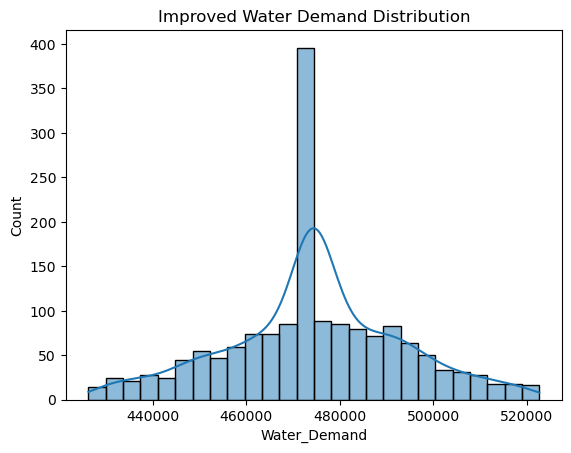

In [220]:
import seaborn as sns

sns.histplot(data['Water_Demand'], kde=True)
plt.title("Improved Water Demand Distribution")
plt.show()